In [ ]:
!pip install torch_geometric ogb

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv

class VanillaGIN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(num_layers):
            layer_in = in_channels if i == 0 else hidden_channels
            layer_out = hidden_channels 

            mlp = nn.Sequential(
                nn.Linear(layer_in, hidden_channels),
                nn.BatchNorm1d(hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, layer_out)
            )
            
            self.convs.append(GINConv(mlp, train_eps=True))
            
            if i < num_layers - 1:
                self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.post_lp = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return x

In [2]:
from torch_geometric.utils import negative_sampling
from ogb.linkproppred import PygLinkPropPredDataset, Evaluator
import time
import torch

if not hasattr(torch, "_original_load"):
    torch._original_load = torch.load

def _patched_load(f, **kwargs):
    kwargs["weights_only"] = False
    return torch._original_load(f, **kwargs)

torch.load = _patched_load

dataset = PygLinkPropPredDataset(name="ogbl-collab")
split_edge = dataset.get_edge_split()

data = dataset[0]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

train_edges    = split_edge['train']['edge'].to(device)
val_edges_pos  = split_edge['valid']['edge'].to(device)
val_edges_neg  = split_edge['valid']['edge_neg'].to(device)
test_edges_pos = split_edge['test']['edge'].to(device)
test_edges_neg = split_edge['test']['edge_neg'].to(device)

print(f"val_edges_neg shape:  {val_edges_neg.shape}")
print(f"test_edges_neg shape: {test_edges_neg.shape}")
print(f"Train edges: {train_edges.shape}")
print(f"Val edges: {val_edges_pos.shape}")
print(f"Test edges: {test_edges_pos.shape}")

def score_edges(z, edges):
    return (z[edges[:, 0]] * z[edges[:, 1]]).sum(dim=-1)

Downloaded 0.11 GB: 100%|██████████| 117/117 [00:05<00:00, 22.06it/s]


Extracting dataset/collab.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 43.19it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 332.49it/s]

Saving...



Done!


val_edges_neg shape:  torch.Size([100000, 2])
test_edges_neg shape: torch.Size([100000, 2])
Train edges: torch.Size([1179052, 2])
Val edges: torch.Size([60084, 2])
Test edges: torch.Size([46329, 2])


In [14]:
evaluator = Evaluator(name='ogbl-collab')

def train(model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    z = model(data.x, data.edge_index)

    pos_score = score_edges(z, train_edges)

    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=min(train_edges.size(0), 100000)
    )

    neg_edges = neg_edge_index.t()
    neg_score = score_edges(z, neg_edges)

    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([
        torch.ones(pos_score.size(0), device=device),
        torch.zeros(neg_score.size(0), device=device)
    ])

    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    z = model(data.x, data.edge_index)

    results = {}
    for split, pos, neg in [
        ('valid', val_edges_pos, val_edges_neg),
        ('test',  test_edges_pos, test_edges_neg)
    ]:
        pos_score = score_edges(z, pos)
        neg_score = score_edges(z, neg)

        hits = evaluator.eval({
            'y_pred_pos': pos_score,
            'y_pred_neg': neg_score,
        })
        results[split] = hits['hits@50']

    return results

In [26]:
model = VanillaGIN(
    in_channels=dataset.num_features,
    hidden_channels=128,
    num_layers=3,
    dropout=0.5,
    out_channels=256,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(model)
print(f"Num parameters: {sum(p.numel() for p in model.parameters()):,}")

VanillaGIN(
  (convs): ModuleList(
    (0-2): 3 x GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (post_lp): Linear(in_features=128, out_features=256, bias=True)
)
Num parameters: 133,379


In [19]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

In [27]:
NUM_EPOCHS = 400
best_val  = 0
best_test = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t = time.time()
    loss = train(model, optimizer, criterion)
    elapsed = time.time() - t
    scheduler.step()

    if epoch % 10 == 0:
        results = evaluate(model)

        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Val Hits@50: {results['valid']:.4f} | "
              f"Test Hits@50: {results['test']:.4f} | "
              f"Time: {elapsed:.2f}s")

        if results['valid'] > best_val:
            best_val  = results['valid']
            best_test = results['test']
            torch.save(model.state_dict(), 'best_gin_vanilla_link.pt')

print(f"\nBest Val  Hits@50: {best_val:.4f}")
print(f"Best Test Hits@50: {best_test:.4f}")

Epoch 010 | Loss: 0.2136 | Val Hits@50: 0.1510 | Test Hits@50: 0.1218 | Time: 0.52s
Epoch 020 | Loss: 0.1886 | Val Hits@50: 0.1439 | Test Hits@50: 0.1144 | Time: 0.53s
Epoch 030 | Loss: 0.1695 | Val Hits@50: 0.1894 | Test Hits@50: 0.1561 | Time: 0.52s
Epoch 040 | Loss: 0.1511 | Val Hits@50: 0.1711 | Test Hits@50: 0.1421 | Time: 0.53s
Epoch 050 | Loss: 0.1364 | Val Hits@50: 0.1597 | Test Hits@50: 0.1326 | Time: 0.52s
Epoch 060 | Loss: 0.1269 | Val Hits@50: 0.1919 | Test Hits@50: 0.1629 | Time: 0.53s
Epoch 070 | Loss: 0.1217 | Val Hits@50: 0.2003 | Test Hits@50: 0.1686 | Time: 0.53s
Epoch 080 | Loss: 0.1159 | Val Hits@50: 0.2110 | Test Hits@50: 0.1800 | Time: 0.52s
Epoch 090 | Loss: 0.1118 | Val Hits@50: 0.2015 | Test Hits@50: 0.1716 | Time: 0.53s
Epoch 100 | Loss: 0.1095 | Val Hits@50: 0.2170 | Test Hits@50: 0.1840 | Time: 0.53s
Epoch 110 | Loss: 0.1072 | Val Hits@50: 0.2124 | Test Hits@50: 0.1803 | Time: 0.53s
Epoch 120 | Loss: 0.1063 | Val Hits@50: 0.2108 | Test Hits@50: 0.1791 | Time

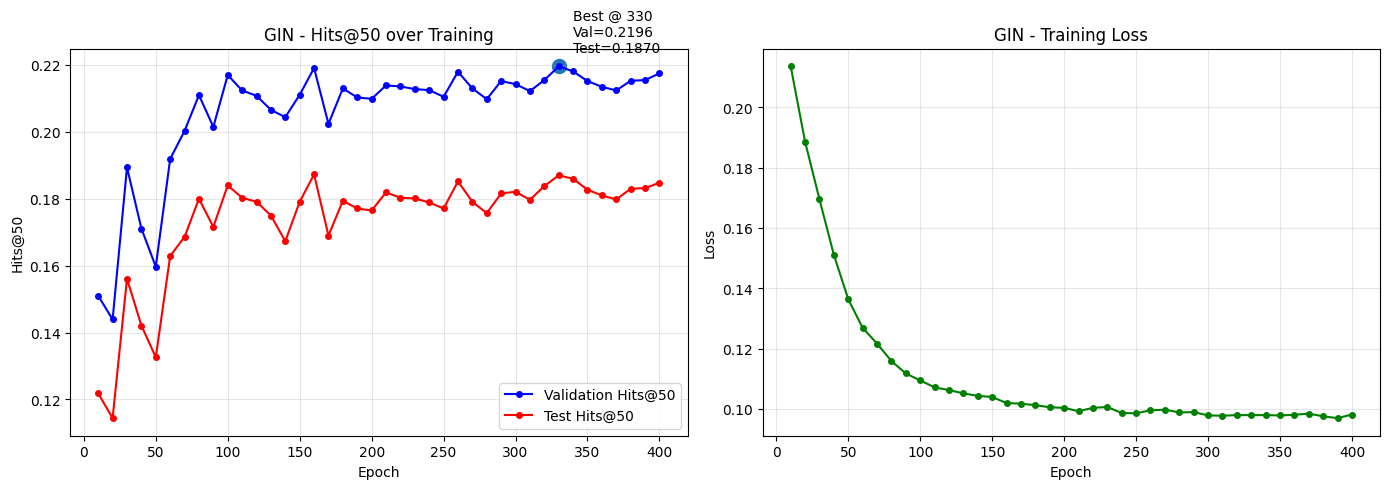

In [28]:
import matplotlib.pyplot as plt

epochs_logged = list(range(10, 401, 10))

val_accs = [
    0.1510, 0.1439, 0.1894, 0.1711, 0.1597,
    0.1919, 0.2003, 0.2110, 0.2015, 0.2170,
    0.2124, 0.2108, 0.2066, 0.2044, 0.2111,
    0.2191, 0.2024, 0.2130, 0.2103, 0.2099,
    0.2139, 0.2136, 0.2128, 0.2125, 0.2105,
    0.2180, 0.2130, 0.2098, 0.2152, 0.2143,
    0.2122, 0.2155, 0.2196, 0.2181, 0.2152,
    0.2135, 0.2124, 0.2153, 0.2155, 0.2175
]

test_accs = [
    0.1218, 0.1144, 0.1561, 0.1421, 0.1326,
    0.1629, 0.1686, 0.1800, 0.1716, 0.1840,
    0.1803, 0.1791, 0.1750, 0.1673, 0.1791,
    0.1873, 0.1690, 0.1794, 0.1771, 0.1765,
    0.1819, 0.1803, 0.1801, 0.1789, 0.1771,
    0.1852, 0.1791, 0.1757, 0.1816, 0.1821,
    0.1797, 0.1838, 0.1870, 0.1860, 0.1827,
    0.1810, 0.1798, 0.1830, 0.1832, 0.1848
]

losses = [
    0.2136, 0.1886, 0.1695, 0.1511, 0.1364,
    0.1269, 0.1217, 0.1159, 0.1118, 0.1095,
    0.1072, 0.1063, 0.1052, 0.1044, 0.1040,
    0.1020, 0.1018, 0.1013, 0.1006, 0.1004,
    0.0993, 0.1004, 0.1007, 0.0987, 0.0986,
    0.0996, 0.0998, 0.0989, 0.0990, 0.0979,
    0.0978, 0.0980, 0.0980, 0.0980, 0.0979,
    0.0981, 0.0985, 0.0976, 0.0970, 0.0982
]

best_idx = val_accs.index(max(val_accs))
best_epoch = epochs_logged[best_idx]
best_val = val_accs[best_idx]
best_test = test_accs[best_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_logged, val_accs, 'b-o', label='Validation Hits@50', markersize=4)
ax1.plot(epochs_logged, test_accs, 'r-o', label='Test Hits@50', markersize=4)

ax1.scatter(best_epoch, best_val, s=100)
ax1.annotate(
    f'Best @ {best_epoch}\nVal={best_val:.4f}\nTest={best_test:.4f}',
    (best_epoch, best_val),
    textcoords="offset points",
    xytext=(10, 10)
)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Hits@50')
ax1.set_title('GIN - Hits@50 over Training')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_logged, losses, 'g-o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('GIN - Training Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

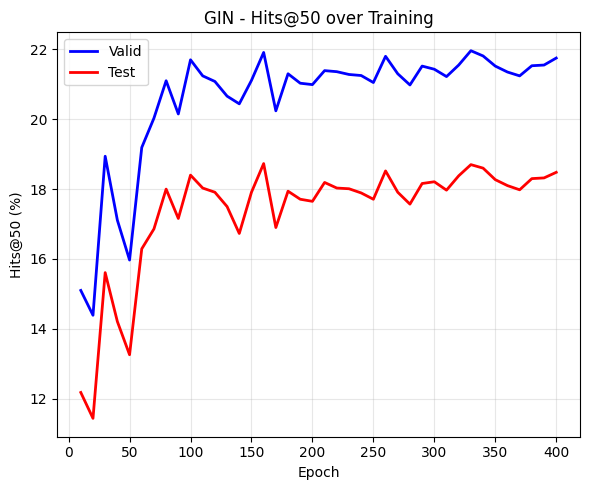

In [29]:
plt.figure(figsize=(6,5))

plt.plot(epochs_logged, [x*100 for x in val_accs], 'b-', label='Valid', linewidth=2)
plt.plot(epochs_logged, [x*100 for x in test_accs], 'r-', label='Test', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Hits@50 (%)')
plt.title('GIN - Hits@50 over Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
@torch.no_grad()
def get_scores_from_embeddings(h, predictor, split_edge, batch_size):
    predictor.eval()

    pos_edge = split_edge['test']['edge'].to(h.device)
    neg_edge = split_edge['test']['edge_neg'].to(h.device)

    pos_scores, neg_scores = [], []

    for perm in DataLoader(range(pos_edge.size(0)), batch_size):
        edge = pos_edge[perm].t()
        pos_scores.append(
            predictor(h[edge[0]], h[edge[1]]).squeeze().cpu()
        )

    for perm in DataLoader(range(neg_edge.size(0)), batch_size):
        edge = neg_edge[perm].t()
        neg_scores.append(
            predictor(h[edge[0]], h[edge[1]]).squeeze().cpu()
        )

    return torch.cat(pos_scores).numpy(), torch.cat(neg_scores).numpy()

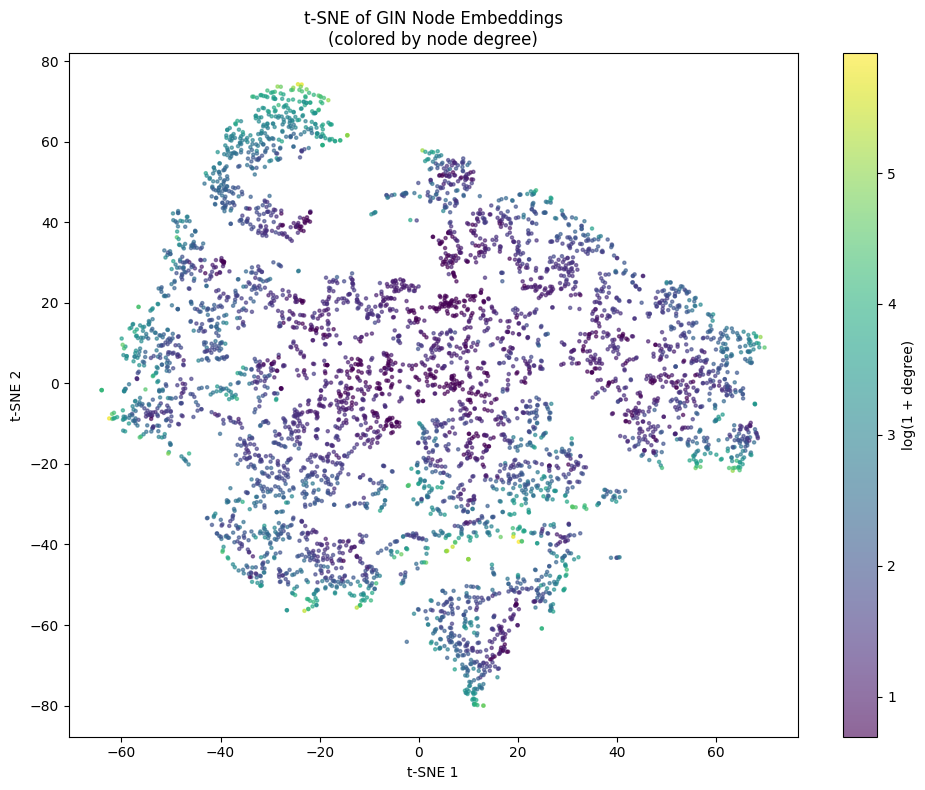

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

if 'embeddings' not in globals() or 'node_idx' not in globals():
    with torch.no_grad():
        model.eval()
        h = model(data.x, data.edge_index)

        num_nodes = min(5000, h.size(0))
        node_idx = torch.randperm(h.size(0))[:num_nodes]

        embeddings = h[node_idx].cpu().numpy()
        node_idx = node_idx.cpu().numpy()

src, dst = data.edge_index.cpu()
deg = torch.zeros(data.num_nodes, dtype=torch.long)
deg.scatter_add_(0, src, torch.ones_like(src))

sampled_degrees = deg[node_idx].numpy()

if 'embeddings_2d' not in globals():
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=np.log1p(sampled_degrees),
    cmap='viridis',
    s=5,
    alpha=0.6
)

plt.colorbar(scatter, ax=ax, label='log(1 + degree)')
ax.set_title('t-SNE of GIN Node Embeddings\n(colored by node degree)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('/kaggle/working/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()